#### Parameters in the data: 

| Parameter | Range (approx) | Physical meaning |
|---|---|---|
| `m1` [M☉] | ~1,000 – 900,000 M☉ | Mass of the central **Intermediate Mass Black Hole (IMBH)**. The dominant body in the system. Sets the orbital timescales, the ISCO frequency $f_\mathrm{ISCO} = c^3 / (6^{3/2} \pi G m_1)$ where the inspiral terminates, and the physical size of the DM spike $r_\mathrm{sp}$ via equation (3). Since $f_\mathrm{ISCO} \propto 1/m_1$, a heavier IMBH means a lower termination frequency — this is why LISA (sensitive at $10^{-3}$–$10^{-2}$ Hz) is the target detector, not LIGO. |
| `m2` [M☉] | ~3 – 100 M☉ | Mass of the **inspiraling compact object** (stellar-mass black hole or neutron star). Determines how strongly the small body feels dynamical friction — a heavier $m_2$ loses orbital energy to friction faster (note $\dot{E}_\mathrm{DF} \propto m_2^2$), shortening the inspiral and increasing the accumulated dephasing. The ratio $q = m_2/m_1 \ll 1$ is what makes this an *extreme* mass ratio inspiral. |
| `gsp` ($\gamma_\mathrm{sp}$) | ~2.0 – 2.5 | **Power-law slope of the DM density spike**: $\rho_\mathrm{DM}(r) \propto (r_\mathrm{sp}/r)^{\gamma_\mathrm{sp}}$. A steeper slope means DM is more concentrated near the center, producing stronger dynamical friction and more dephasing as the compact object spirals inward. The benchmark value $\gamma_\mathrm{sp} = 7/3 \approx 2.33$ arises from $\gamma_\mathrm{sp} = (9 - 2\alpha)/(4 - \alpha)$ when an IMBH grows adiabatically at the center of an NFW halo with inner slope $\alpha = 1$. The range 2.0–2.5 brackets realistic astrophysical scenarios. |
| `rhosp` [M☉/pc³] | ~10 – ~10,000 M☉/pc³ | **Density normalization of the DM spike** at the reference radius $r_\mathrm{sp}$. Controls the overall amplitude of the DM distribution — a higher $\rho_\mathrm{sp}$ means more DM mass at every radius, more dynamical friction, and a larger dephasing signal. Together with $\gamma_\mathrm{sp}$, it fully specifies the initial density profile $\rho_\mathrm{DM}(r) = \rho_\mathrm{sp}(r_\mathrm{sp}/r)^{\gamma_\mathrm{sp}}$ used by the simulator. |
| `fGW` [Hz] | ~$10^{-3}$ – ~5 Hz | **Gravitational wave frequency** at which the dephasing is evaluated. Related to orbital separation $r$ by $f_\mathrm{GW} = (1/\pi)\sqrt{Gm_1/r^3}$, so it directly tracks the inspiral progress — low frequency means the compact object is still far from the IMBH, high frequency means it is close to merger. Each sample has its own frequency grid of 200 points running up to $f_\mathrm{ISCO} \propto 1/m_1$. This is the 5th input to the MLP. |
| `dPh` [rad] | ~$10^{-4}$ – ~$10^{6}$ rad | **The dephasing** $\Delta\Phi(f)$ — the quantity the MLP predicts. It is the accumulated difference in GW phase between a system with a DM spike and an identical vacuum system, computed as $\Delta\Phi(f) = 2\pi \int_{f}^{f_\mathrm{ISCO}} \frac{f'}{(\dot{f}^\mathrm{vac})^2} \delta\dot{f}(f')\, df'$. Large values at low frequencies reflect a long history of DM-accelerated inspiral; the value always falls to zero at $f_\mathrm{ISCO}$ by construction. The ~10 orders of magnitude dynamic range across the dataset is why we train on $\log_{10}(\Delta\Phi)$. |

#### The general idea: 
- each training set is a 5-tuple $\rightarrow$ scalar: ```(log10(m1), log10(m2), gsp, log10(rhosp), log10(f))  →  log10(ΔΦ)```
- from 10,000 files x 200 frequency points, this means 2,000,000 training pairs: a simple regression problem (no sequence modeling needed yet)



#### Key preprocessing decisions: 
- why log-transform inputs and output? 
    - ```m1```: ranges from 1e3 to 9e5 (factor 900x); linear scale would make NN spend most time on large-m1 systems
    - ```rhosp```: same vibes as m1
    - ```f```: 4 O.O.M. 
    - ```dph``` spans 10 O.O.M. -- log turns this into much smoother regression target (~-4 to 6) 
    - ```gsp``` is already narrow range (only ~2.0 - 2.5) so can stay linear

#### Train/val/test split:
- Split at the file level (i.e., by sample index), not at the row level. If you split row-by-row, the same physical system's nearby frequency points could appear in both train and test — that would leak information and give falsely optimistic results.

#### Normalization:
- After log-transforming, apply standard zero-mean, unit-variance scaling on the training set, then apply the same transform to val/test.

#### Architecture: 
Simple starting MLP: 
```Input (5) → Linear(5,64) → ReLU → Linear(64,128) → ReLU → Linear(128,64) → ReLU → Linear(64,1)```

- ```Linear(5, 64)```: Takes 5 numbers and produces 64. Each of the 64 outputs is weighted sum of all 5 inputs, plus a bias term. So this layer is 5x64 + 64 = 384 learnable parameters. At the start, these weights are random; by end of training they've learned something like "m1 and f together seem to matter a lot for dephasing". 

- ```ReLU```: Applied element-wise to those 64 numbers: replace any negative value with 0, leaves positive values unchanged. No learnable parameters. Without this (or similar nonlinearity), stacking linear layers would just collapse into a single linear layer, and you could never fit a curved surface. 

- ```Linear(64, 128)```: Takes those 64 numbers (some now zeroed out by the ReLU) and produces 128 numbers. The network is widening here -- it's building up a richer internal representation. (64x128 + 128 = 8320 parameters) 

- ```ReLU```: same as before

- ```Linear(128, 64)```: Now narrows back down from 128 → 64. The network is compressing. Has to summarize what it learned into fewer numbers. 128x64 + 64 = 8256 parameters

- ```ReLU```: same as before

- ```Linear(64, 1)```: final compression to single number -- predicted $log10(\Delta\Phi)$. 64x1 + 1 = 65 parameters. 

So the whole network has roughly 17,000 parameters total, all trained by backpropagation to minimize MSE between predicted and true log10(dph). Hourglass shape (5 → 64 → 128 → 64 → 1) is a common pattern: expand first to give network room to find structure in the inputs, then compress back down to the answer. 

Loss: MSE on ```log10(dph)``` -- equivalent to relative error in log-space, which makes sense given dynamic range. 

In [2]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt

### Step 1: Data loading — parser + building values for the flat (params, f) → $\Delta\Phi$ table

In [ ]:
def parse_sample(filepath):
    """
    Parses a single dephasing_sample_N.csv file.
    Returns:
        params: dict with m1, m2, gsp, rhosp (as floats)
        freqs:  numpy array of GW frequencies [Hz]
        dph:    numpy array of dephasing values [rad]
    """
    # Row 0 has the params encoded in column names, row 1 has fGW/dPh headers
    raw = pd.read_csv(filepath, skiprows=0)
    
    # Extract physical parameters from column name strings
    col_names = raw.columns.tolist()
    params = {}
    for col in col_names:
        if '=' in col:
            key, val = col.strip().split('=')
            params[key.strip()] = float(val.strip())
    
    # Skip row 0 (the fGW/dPh header row) and read actual data
    data = pd.read_csv(filepath, skiprows=1)
    freqs = data['fGW[Hz]'].values.astype(float)
    dph   = data['dPh[rad]'].values.astype(float)
    
    return params, freqs, dph


def load_all_samples(data_dir='data/'):
    """
    Loads all dephasing_sample_*.csv files and process using parse_sample.
    Returns a list of (params, freqs, dph) tuples, one per file.
    """
    filepaths = sorted(glob.glob(f'{data_dir}dephasing_sample_*.csv'))
    print(f"Found {len(filepaths)} files")
    
    all_samples = []
    for fp in filepaths:
        try:
            params, freqs, dph = parse_sample(fp)
            all_samples.append((params, freqs, dph))
        except Exception as e:
            print(f"  Warning: skipped {fp} — {e}")
    
    print(f"Successfully loaded {len(all_samples)} samples")
    return all_samples


# --- Run it ---
all_samples = load_all_samples('data/')

# Sanity check on the first sample
params, freqs, dph = all_samples[0]
print("\nFirst sample:")
print("  params:", params)
print("  freq range: [{:.4e}, {:.4e}] Hz".format(freqs.min(), freqs.max()))
print("  dph range:  [{:.4e}, {:.4e}] rad".format(dph.min(), dph.max()))
print("  num points:", len(freqs))

Found 10000 files
Successfully loaded 10000 samples

First sample:
  params: {'m1': 101268.01, 'm2': 8.197, 'gsp': 2.138, 'rhosp': 2904.897}
  freq range: [3.2420e-03, 4.3422e-02] Hz
  dph range:  [0.0000e+00, 2.5176e+03] rad
  num points: 200


Example: ```parse_sample``` on one individual file, and plot: 

{'m1': 33114.307, 'm2': 8.44, 'gsp': 2.306, 'rhosp': 36.793}


Text(0, 0.5, '$\\Delta\\Phi$ [Hz]')

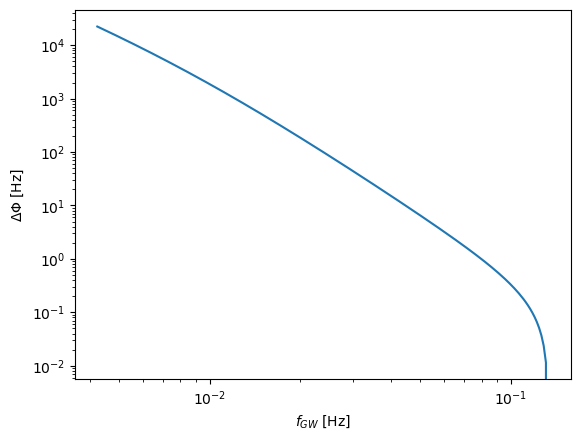

In [ ]:
params_5, freqs_5, dph_5 = parse_sample('data/dephasing_sample_5.csv')
print(params_5)

plt.loglog(freqs_5, dph_5)
plt.xlabel('$f_{GW}$ [Hz]')
plt.ylabel('$\Delta\Phi$ [Hz]')

### Step 2. Dataset & DataLoader — PyTorch Dataset class, train/val/test split by file

#### On the "flattening" aspect of this step: 

(*extend the VSCode window to look at this properly*)

### Before flattening — the raw structure

After Step 1, `all_samples` is a nested structure. Each element is one physical system:

```python
all_samples[0]  →  params = {m1: 101268, m2: 8.2, gsp: 2.14, rhosp: 2904}
                   freqs  = [0.00324, 0.00328, 0.00333, ..., 0.04342]  # 200 numbers
                   dph    = [2517.6,  2405.1,  2297.4,  ..., 0.0    ]  # 200 numbers

all_samples[1]  →  params = {m1: 617264, m2: 86.7, gsp: 2.17, rhosp: 1558}
                   freqs  = [0.00110, 0.00111, ..., 0.01025]           # 200 numbers
                   dph    = [30.3,    29.1,    ..., 0.0    ]           # 200 numbers

# ... (10,000 of these)
```

It is a list of lists essentially — 10,000 systems, each containing 200 points.
This is a natural way to store simulation output, but PyTorch's `Dataset` cannot
work with this structure. It needs to be able to say *"give me example number 47,832"*
and get back a single input vector and a single target value instantly.

---

### After flattening — what the MLP actually sees

Each individual $(f, \Delta\Phi)$ pair becomes its own independent training example,
with the four physical parameters **repeated** alongside it:

```python
row 0:       [log10(101268), log10(8.2), 2.14, log10(2904), log10(0.00324)]  →  log10(2517.6)
row 1:       [log10(101268), log10(8.2), 2.14, log10(2904), log10(0.00328)]  →  log10(2405.1)
# ...
row 199:     [log10(101268), log10(8.2), 2.14, log10(2904), log10(0.04342)]  →  log10(0.0)  # skipped (d <= 0)
row 200:     [log10(617264), log10(86.7), 2.17, log10(1558), log10(0.00110)] →  log10(30.3)
# ...
row ~2,000,000: last point of last sample
```

This is what **"flat"** means — instead of a nested hierarchy of files and points,
you have one big 2D table where every row is a self-contained example. The shape
ends up being roughly $(2{,}000{,}000 \times 5)$ for $X$ and $(2{,}000{,}000,)$ for $y$.

---

### Why is this necessary?

The MLP has no concept of "files" or "sequences". It just takes a vector of 5 numbers
and outputs 1 number. It does not know or care that rows 0–198 all came from the same
physical system — and that is fine, because the question it is answering is simply:

> *Given these 5 values of $(m_1, m_2, \gamma_\mathrm{sp}, \rho_\mathrm{sp}, f)$, what is $\Delta\Phi$?*

Each row is a complete, independent answer to that question. The flattening is what
turns your simulation output into a format that matches the question the MLP is being
trained to answer.

---

#### Actual Code for Step 2: 

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
# Dataset is a PyTorch abstract class — you subclass it and tell it what your data looks like. 
# DataLoader wraps a Dataset and handles batching, shuffling, and feeding data into the training loop automatically.

class DephasingDataset(Dataset):

    # building the flat table
    def __init__(self, all_samples): 
        self.X = []
        self.y = []

        # ----- core flattening step. ------
        # Each of the 10,000 files has 200 (f, Δφ) pairs. 
        # We loop over every file and every point inside it, turning the nested structure into one big flat list of individual training examples. 
        # The if d <= 0 skips the final point of each sample where dephasing is exactly 0 — we can't take log10(0).
        for params, freqs, dph in all_samples:

            # grabbing metadata 
            m1     = params['m1'] 
            m2     = params['m2']
            gsp    = params['gsp']
            rhosp  = params['rhosp']
            # grabbing freq vs. dph data
            for f, d in zip(freqs, dph):
                if d <= 0:
                    continue

            # ----- building the input vector -----
            # This is the log-transform. Four of the five inputs span orders of magnitude and are log-transformed. 
            # gsp lives in a narrow range (~2.0–2.5) so it stays linear. 
            # The target y is also log-transformed because dephasing spans ~10 orders of magnitude.

                # build vector w/ transforms
                x = [
                    np.log10(m1), # log
                    np.log10(m2), # log
                    gsp, # stays linear because narrow range
                    np.log10(rhosp), # log
                    np.log10(f) # log
                ]
                self.X.append(x) # append transformed params
                self.y.append(np.log10(d)) # append the dphi

        # ----- converting to tensors: ----- 
        # PyTorch operates on tensors, not numpy arrays or Python lists. float32 (32-bit floating point) 
        # is standard for neural network training — float64 would double the memory usage for no meaningful gain in this context.
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)

        # ----- normalization -----
        self.X_mean = self.X.mean(dim=0)
        self.X_std  = self.X.std(dim=0)
        self.X = (self.X - self.X_mean) / self.X_std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# --- Split by sample index, not by row ---
n_samples  = len(all_samples)
n_train    = int(0.7 * n_samples)
n_val      = int(0.15 * n_samples)

indices    = torch.randperm(n_samples)
train_idx  = indices[:n_train]
val_idx    = indices[n_train : n_train + n_val]
test_idx   = indices[n_train + n_val:]

train_samples = [all_samples[i] for i in train_idx]
val_samples   = [all_samples[i] for i in val_idx]
test_samples  = [all_samples[i] for i in test_idx]

# --- Build datasets ---
train_dataset = DephasingDataset(train_samples)
val_dataset   = DephasingDataset(val_samples)
test_dataset  = DephasingDataset(test_samples)

# --- Apply train statistics to val and test ---
val_dataset.X  = (val_dataset.X * val_dataset.X_std + val_dataset.X_mean)
val_dataset.X  = (val_dataset.X - train_dataset.X_mean) / train_dataset.X_std

test_dataset.X = (test_dataset.X * test_dataset.X_std + test_dataset.X_mean)
test_dataset.X = (test_dataset.X - train_dataset.X_mean) / train_dataset.X_std

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1024, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1024, shuffle=False)

# --- Sanity checks ---
print(f"Total training rows:   {len(train_dataset)}")
print(f"Total val rows:        {len(val_dataset)}")
print(f"Total test rows:       {len(test_dataset)}")

X_batch, y_batch = next(iter(train_loader))
print(f"\nOne batch  — X shape: {X_batch.shape}, y shape: {y_batch.shape}")
print(f"X sample (first row): {X_batch[0]}")
print(f"y sample (first row): {y_batch[0]:.4f}  (log10 of dephasing in rad)")

### Step 3: Model — MLP definition

### Step 4: Training loop — with validation loss tracking

### Step 5: Evaluation — plot predicted vs true Δφ on test samples